## Importing libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing dataset and reading it

My dataset contains information on different IMDb movies. It can be easily analyzed as there are various indicators in it.

In [ ]:
movies_data_path = 'dataset/imdb_top_1000.csv.xls'
movies_data = pd.read_csv(movies_data_path)

In [ ]:
movies_data.head()

,Series_Title,Released_Year,Certificate,Runtime,Genre,Subgenre,Subgenre 1,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142,Drama,NaN,NaN,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0
1,The Godfather,1972,A,175,Crime,Drama,NaN,9.2,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0
2,The Dark Knight,2008,UA,152,Action,Crime,Drama,9.0,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0
3,The Godfather: Part II,1974,A,202,Crime,Drama,NaN,9.0,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0
4,12 Angry Men,1957,U,96,Crime,Drama,NaN,9.0,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0


In [ ]:
movies_data.tail()

,Series_Title,Released_Year,Certificate,Runtime,Genre,Subgenre,Subgenre 1,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
995,Breakfast at Tiffany's,1961,A,115,Comedy,Drama,Romance,7.6,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN
996,Giant,1956,G,201,Drama,Western,NaN,7.6,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN
997,From Here to Eternity,1953,Passed,118,Drama,Romance,War,7.6,85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,30500000.0
998,Lifeboat,1944,NaN,97,Drama,War,NaN,7.6,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN
999,The 39 Steps,1935,NaN,86,Crime,Mystery,Thriller,7.6,93.0,Alfred Hitchcock,Robert Donat,Madeleine Carroll,Lucie Mannheim,Godfrey Tearle,51853,NaN


## Main hypothesis

Films released between 2000 and 2020 have a tendency to have higher IMDb ratings, which is particularly noticeable in the action genre. Moreover, there is a relationship between runtime and IMDb rating: for films released before 2000, longer runtimes are negatively correlated with IMDb ratings. However, for films released after 2000, a completely different pattern can be observed: longer runtimes are more likely to be associated with higher IMDb ratings. 

## Main statistics

In order to make the analysis less complicated and more convenient for me, I would like to output and then manipulate some statistics.

In [ ]:
movies_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   1000 non-null   object 
 1   Released_Year  1000 non-null   object 
 2   Certificate    899 non-null    object 
 3   Runtime        1000 non-null   int64  
 4   Genre          1000 non-null   object 
 5   Subgenre       895 non-null    object 
 6   Subgenre 1     646 non-null    object 
 7   IMDB_Rating    1000 non-null   float64
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    float64
dtypes: float64(3), int64(2), object(11)
memory usage: 125.1+ KB


With the help of this table I will be able to carry out data cleanup later on.

I also would like to output general descriptive statistics with the help of the 'describe()' function. However, I am going to use the transposed function as it is more convenient for me.

In [ ]:
movies_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Runtime,1000.0,1.228910e+02,2.809367e+01,45.0,103.00,119.0,137.00,321.0
IMDB_Rating,1000.0,7.949300e+00,2.754912e-01,7.6,7.70,7.9,8.10,9.3
Meta_score,843.0,7.797153e+01,1.237610e+01,28.0,70.00,79.0,87.00,100.0
No_of_Votes,1000.0,2.736929e+05,3.273727e+05,25088.0,55526.25,138548.5,374161.25,2343110.0
Gross,831.0,6.803475e+07,1.097500e+08,1305.0,3253559.00,23530892.0,80750893.50,936662225.0


Now I am going to check which columns contain numerical features and which columns have categorical features in them.

In [ ]:
c = list(movies_data.columns)
numerical = []
categorical = []
for i in c:
    if movies_data[i].dtype == 'object':
        categorical.append(i)
    else:
        numerical.append(i)
print('\nNumerical columns:', ', '.join(numerical))
print('Categorical columns:', ', '.join(categorical))


Numerical columns: Runtime, IMDB_Rating, Meta_score, No_of_Votes, Gross
Categorical columns: Series_Title, Released_Year, Certificate, Genre, Subgenre, Subgenre 1, Director, Star1, Star2, Star3, Star4


## Data cleanup

First of all, I need to check if there are any missing values in my dataset. I can do that with the help of the 'isna()' function which returns a DataFrame of the same shape as the given one, but with 'True' where the values are 'NaN' (Not a Number, i.e., missing values) and 'False' where the values are not missing.

In [ ]:
movies_data.isna().sum()

Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
Subgenre         105
Subgenre 1       354
IMDB_Rating        0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

It is apparent that there are some missing values that I need to deal with. I would like to replace all missing values in categorical columns with 'Unknown'.

In [ ]:
categorical_columns = ['Series_Title', 'Certificate', 'Genre', 'Subgenre', 'Subgenre 1', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']

for column in categorical_columns:
    movies_data[column] = movies_data[column].fillna('Unknown')

missing_values_after = movies_data.isnull().sum()
print("\nMissing values after handling:")
print(missing_values_after[missing_values_after > 0])


Missing values after handling:
Meta_score    157
Gross         169
dtype: int64


I am going to handle the 'Released_Year' column separately as all of the indicators in it are numbers yet they are considered to be categorical values.

First of all, I intend on making sure that there are no letters in the column using the 'str.extract(r'(\d+)])' construction, which gets rid off of all non-digit characters.

In [ ]:
movies_data['Released_Year'] = movies_data['Released_Year'].str.extract(r'(\d+)')[0]

After making sure that there are no non-digit characters in the column, I need to check if there are any missing values in the column. If so, I will replace them with '0'. Then I am going to change the data type of the column. It will make my future analysis much easier.

In [ ]:
column = ['Released_Year']

for i in column:
    movies_data[i] = movies_data[i].fillna(0)

In [ ]:
movies_data['Released_Year'] = movies_data['Released_Year'].astype(int)

However, for the data in the column to remain precise, I need to make sure that the missing values are replaced by the mean value of the 'Released_Year' column.

In [ ]:
mean_value = movies_data['Released_Year'].replace(0, pd.NA).mean()

movies_data['Released_Year'] = movies_data['Released_Year'].replace(0, mean_value)

Now I am left with two numerical columns that contain missing values. As the number of empty cells in each of them is over 150, I am going to put mean values there instead as this will make my dataset more precise.

In [ ]:
numerical_columns = ['Meta_score', 'Gross']

for column in numerical_columns:
    movies_data[column] = movies_data[column].fillna(movies_data[column].mean())

missing_values_after = movies_data.isnull().sum()
print("\nMissing values after handling:")
print(missing_values_after[missing_values_after > 0])


Missing values after handling:
Series([], dtype: int64)


Finally, there are no missing values in the dataset.

Now I want to check if there any duplicate rows in the dataset.

In [ ]:
movies_data.duplicated().sum()

0

Luckily, no duplicate rows were found. Now I would like to check if all of the columns have the correct data type by using the 'info()' function once again.

In [ ]:
movies_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   1000 non-null   object 
 1   Released_Year  1000 non-null   float64
 2   Certificate    1000 non-null   object 
 3   Runtime        1000 non-null   int64  
 4   Genre          1000 non-null   object 
 5   Subgenre       1000 non-null   object 
 6   Subgenre 1     1000 non-null   object 
 7   IMDB_Rating    1000 non-null   float64
 8   Meta_score     1000 non-null   float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          1000 non-null   float64
dtypes: float64(4), int64(2), object(10)
memory usage: 125.1+ KB


I also would like to get rid of some of the columns that I do not plan on using in the future.

In [ ]:
movies_data = movies_data.drop(['No_of_Votes', 'Gross'], axis = 1, errors = 'ignore')
movies_data = movies_data.drop(['Certificate', 'Subgenre', 'Subgenre 1', 'Star1', 'Star2', 'Star3', 'Star4'], axis = 1, errors = 'ignore')
movies_data.tail()

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Meta_score,Director
995,Breakfast at Tiffany's,1961.0,115,Comedy,7.6,76.0,Blake Edwards
996,Giant,1956.0,201,Drama,7.6,84.0,George Stevens
997,From Here to Eternity,1953.0,118,Drama,7.6,85.0,Fred Zinnemann
998,Lifeboat,1944.0,97,Drama,7.6,78.0,Alfred Hitchcock
999,The 39 Steps,1935.0,86,Crime,7.6,93.0,Alfred Hitchcock


Finally, all of the data in the dataset is clean and ready to be analyzed.

## Data transformation

Now I am going to perfome some manipulations with the data to make it more readable and suitable for the analysis ahead.

I would like to add a new column 'IMDB_Category', which is going to return a keyword based off the movie's IMDb rating. I am going to write conditions for the ratings from 7 to 10 as the dataset only contains information on the movies with the rating of 7 and more.

In [ ]:
def rating_category(rating):
    if rating == 10.0:
        return 'Masterpiece'
    elif rating >= 9.0:
        return 'Excellent'
    elif rating >= 8.0:
        return 'Very good'
    elif rating >= 7.0:
        return 'Good'

movies_data['IMDB_Category'] = movies_data['IMDB_Rating'].apply(rating_category)

It will be also convenient for me to add a new column called 'Runtime_Category'. This will make my future analysis and visualization processes much easier. 

In [ ]:
def runtime_category(runtime):
    if runtime in range(40, 90):
        return 'Feature-Length'
    elif runtime in range(90, 120):
        return 'Average-Length'
    elif runtime in range(120, 150):
        return 'Long'
    elif runtime in range(150, 180):
        return 'Epic'
    elif runtime in range(180, 300):
        return 'Very Long'

movies_data['Runtime_Category'] = movies_data['Runtime'].apply(runtime_category)

Finally, to make my dataset as convenient for analysis as possible, I am going to create another column called 'Release_Period', which is going to divide movies into two categories: 'Before 2000' 'In and After 2000'. But first it will be necessary to change the data type of the said column with the help of the 'astype()' function, which changes the type of the data in the chosen column.

In [ ]:
movies_data['Released_Year'] = movies_data['Released_Year'].astype(int)

In [ ]:
def release_period(year):
    if year in range(0, 2000):
        return 'Before 2000'
    elif year in range(2000, 2021):
        return 'In and After 2000'
        
movies_data['Release_Period'] = movies_data['Released_Year'].apply(release_period)

Let's see what the dataset looks like after my manipulations.

In [ ]:
movies_data.tail()

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Meta_score,Director,IMDB_Category,Runtime_Category,Release_Period
995,Breakfast at Tiffany's,1961,115,Comedy,7.6,76.0,Blake Edwards,Good,Average-Length,Before 2000
996,Giant,1956,201,Drama,7.6,84.0,George Stevens,Good,Very Long,Before 2000
997,From Here to Eternity,1953,118,Drama,7.6,85.0,Fred Zinnemann,Good,Average-Length,Before 2000
998,Lifeboat,1944,97,Drama,7.6,78.0,Alfred Hitchcock,Good,Average-Length,Before 2000
999,The 39 Steps,1935,86,Crime,7.6,93.0,Alfred Hitchcock,Good,Feature-Length,Before 2000


Awesome! Now I can move on to the data analysis.

## Visualization

In order to demonstrate the abilities of my dataset and to work with my hypothesis, I am going to visualize the data given.

First of all, I intend on sketching a pair plot connected with 'Runtime_Category' column as simply using 'Runtime' column in not convenient for me due to the large number of indicators (meanings) in the said column.

I also would like to create my own color palette for the graphs to make them more aesthetically pleasing and suitable for the future analysis.

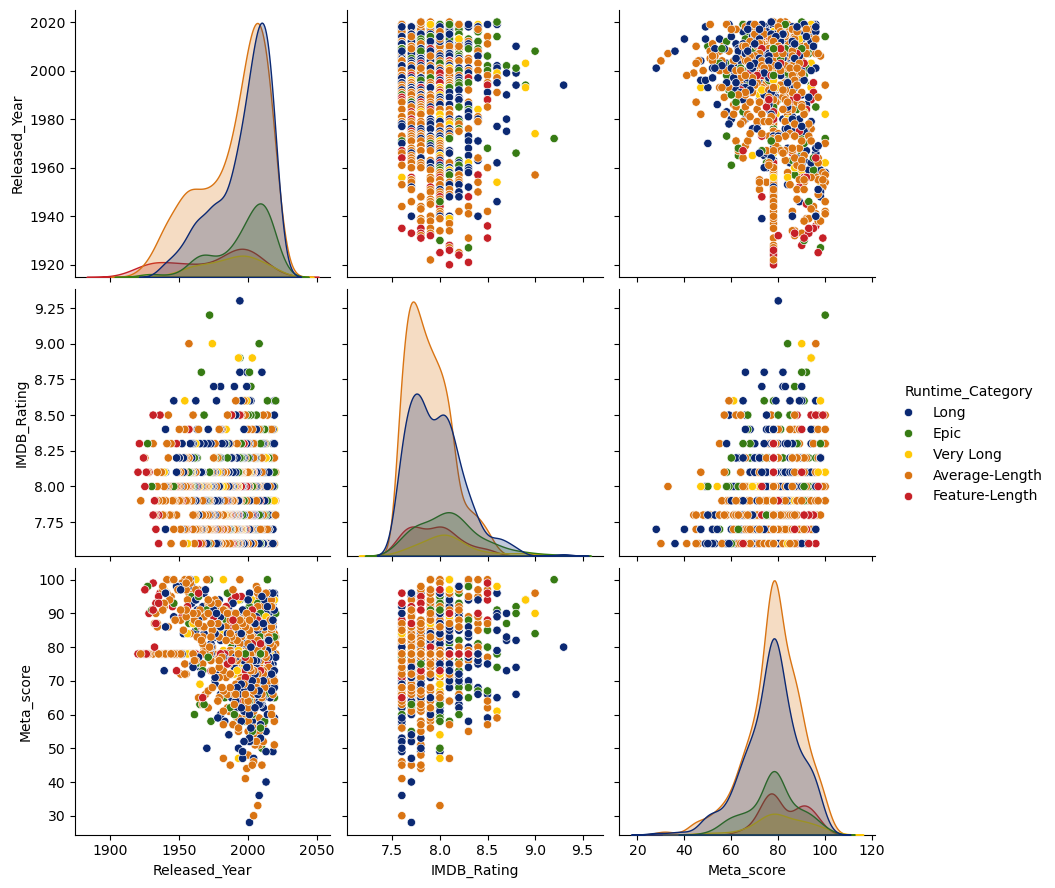

In [ ]:
included_columns = movies_data.columns[movies_data.columns != 'Runtime']
my_palette = sns.color_palette(['#0B2973', '#377B14', '#FFC907', '#D97413', '#C62027'])
movies_data_subset = movies_data[included_columns]
sns.pairplot(movies_data_subset, hue = 'Runtime_Category', height = 3, palette = my_palette)

From the pair plot it is apparent that overall average-length movies tend to be associated with higher IMDb ratings. It is also worth-mentioning that average-length movies gross the most. Long movies are two times less profitable. 

As other indicators are hard to analyse, I am going to make more graphs in order to take a closer look at both categorical and numerical features of the dataset.

First of all, I would like to demonstrate the shift in IMDb ratings, comparing ratings before 2000 and between 2000 and 2020.

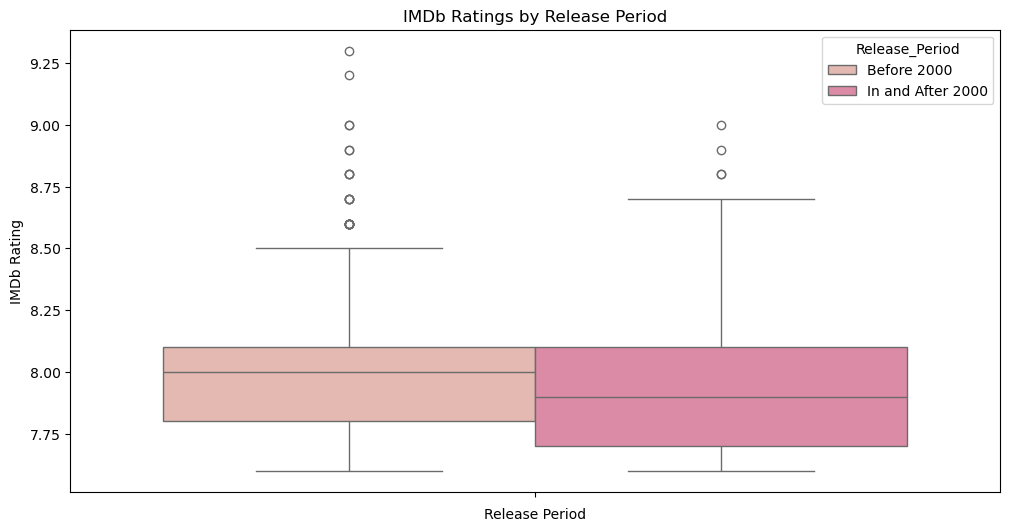

In [ ]:
plt.figure(figsize = (12, 6))
my_palette = sns.color_palette(['#EBB3A9', '#E87EA1'])
sns.boxplot(data = movies_data, hue = 'Release_Period', y = 'IMDB_Rating', palette = my_palette)

plt.title('IMDb Ratings by Release Period')
plt.xlabel('Release Period')
plt.ylabel('IMDb Rating')
plt.show()

As we can see, the median of the left box is higher than the one of the right box. This signifies that the average IMDb rating for movies released before 2000 is higher than the average rating for movies released in and after 2000.

Now I want to create a line plot to demonstrate the change in IMDb ratings of the movies released between 2000 and 2020. 

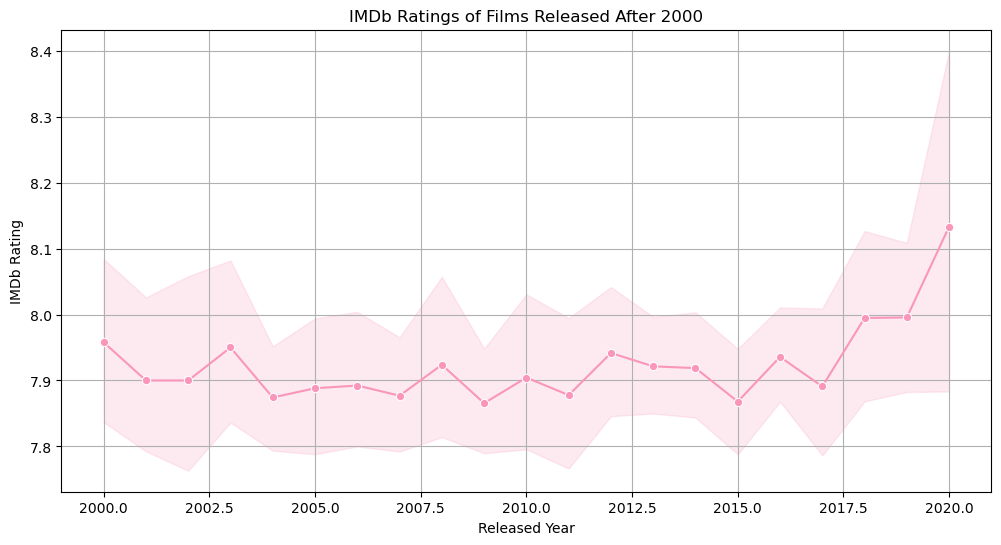

In [ ]:
data_filtered = movies_data[movies_data['Released_Year'] >= 2000]
plt.figure(figsize = (12, 6))
sns.lineplot(data = data_filtered, x = 'Released_Year', y ='IMDB_Rating', marker = 'o', color = '#F996BA')

plt.title('IMDb Ratings of Films Released After 2000')
plt.xlabel('Released Year')
plt.ylabel('IMDb Rating')
plt.grid(True)
plt.show()

It is apparent that the IMDb ratings of the movies released from 2000 to 2017 (not included) are stable enough. However, the IMDb ratings of the movies released between 2017 (included) and 2020 tend to increase as the value of the release year grows.

Secondly, I want to see if there is any correlation between IMDb rating and Metascore. For a better understanding of my analysis, I would like to clarify the difference between the IMDb rating and the Metascore. The IMDb rating is based off a viewer's opinion on a film. Meanwhile, the Metascore is a single score that represents the consensus built by highly respected critics for a movie (or a TV show, a video game, etc.). 

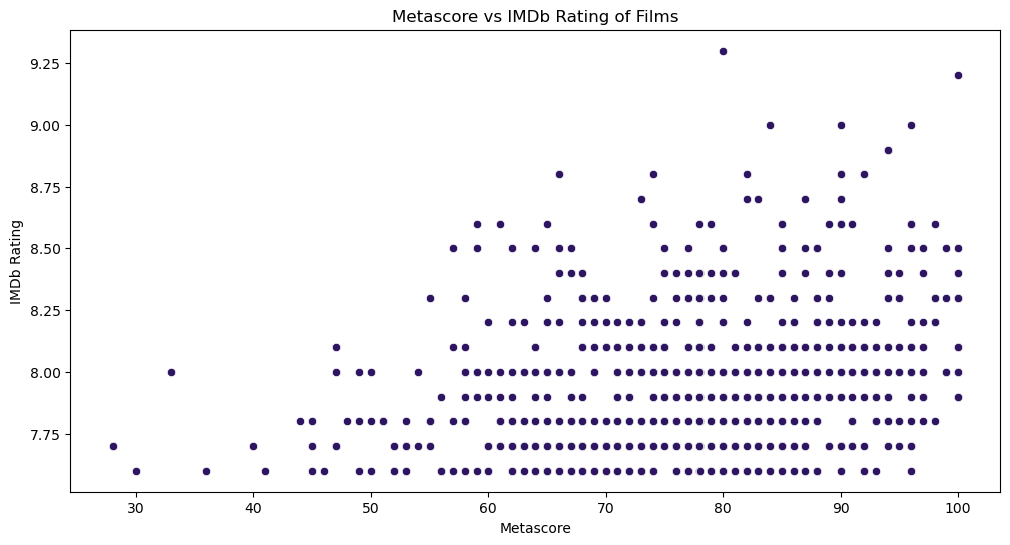

In [ ]:
plt.figure(figsize = (12, 6))  
sns.scatterplot(data = movies_data, x = 'Meta_score', y = 'IMDB_Rating', marker = 'o', color = '#2E1561')

plt.title('Metascore vs IMDb Rating of Films')
plt.xlabel('Metascore')
plt.ylabel('IMDb Rating')
plt.show()

An interesting pattern can be observed here. While films with low Metascore tend to receive low IMDb ratings as well and the general trend is correspondence between Metascore and IMDb rating of a film, films Metascore of which is in between 70 and 90 tend to get the highest IMDb ratings. Movies with Metascore over 90 tend to receive less admiration from the viewers. However, the difference is barely noticeable.

Now I would like to demonstrate the connection between runtime and IMDDb rating for films released before 2000 and after 2000. I am going to create two separate scatter plots.

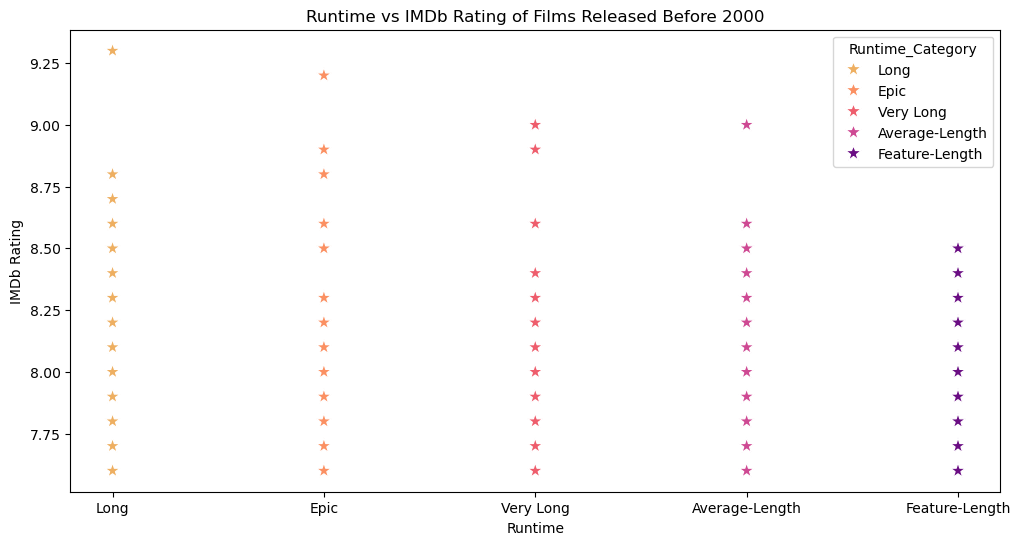

In [ ]:
filtered_data = movies_data[movies_data['Released_Year'] < 2000]
plt.figure(figsize = (12, 6))
my_palette = sns.color_palette(['#EEAF61', '#FB9062', '#EE5D6C', '#CE4993', '#6A0D83'])
sns.scatterplot(data = filtered_data, x = 'Runtime_Category', y = 'IMDB_Rating', hue= 'Runtime_Category', palette = my_palette, marker = "*",  color = '#421E8B', s = 140)

plt.title('Runtime vs IMDb Rating of Films Released Before 2000')
plt.xlabel('Runtime')
plt.ylabel('IMDb Rating')
plt.show()

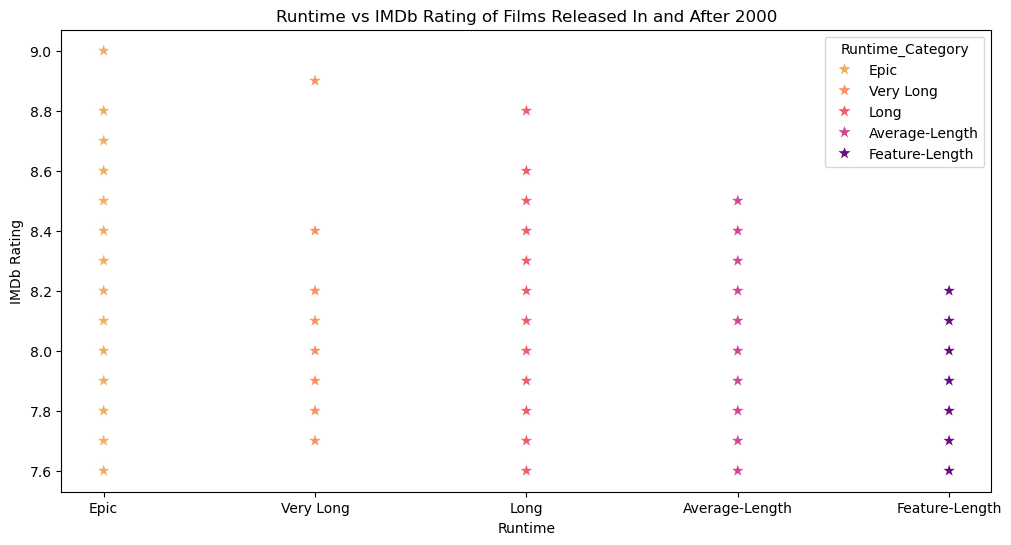

In [ ]:
filtered_data = movies_data[movies_data['Released_Year'] >= 2000]
plt.figure(figsize = (12, 6))
my_palette = sns.color_palette(['#EEAF61', '#FB9062', '#EE5D6C', '#CE4993', '#6A0D83'])
sns.scatterplot(data = filtered_data, x = 'Runtime_Category', y = 'IMDB_Rating', hue= 'Runtime_Category', palette = my_palette, marker = "*",  color = '#421E8B', s = 140)

plt.title('Runtime vs IMDb Rating of Films Released In and After 2000')
plt.xlabel('Runtime')
plt.ylabel('IMDb Rating')
plt.show()

It is obvious that movies released before 2000 tend to get the highest IMDb ratings if they are either long or epic. Similar trend can be observed when it comes to movies released in and after 2000. However, it is worth-mentioning that very long movies released in and after 2000 receive lower IMDb ratings than very long movies released before 2000. 

Now I would like to move on to more detailed analysis. I am going to build a few more complex plots, which are going to help me to approve or disapprove of my hypothesis.

The first more complex plot I am going to build is a side-by-side box plot comparing IMDb ratings for films released before 2000 and in and after 2000 and grouped by genres. 

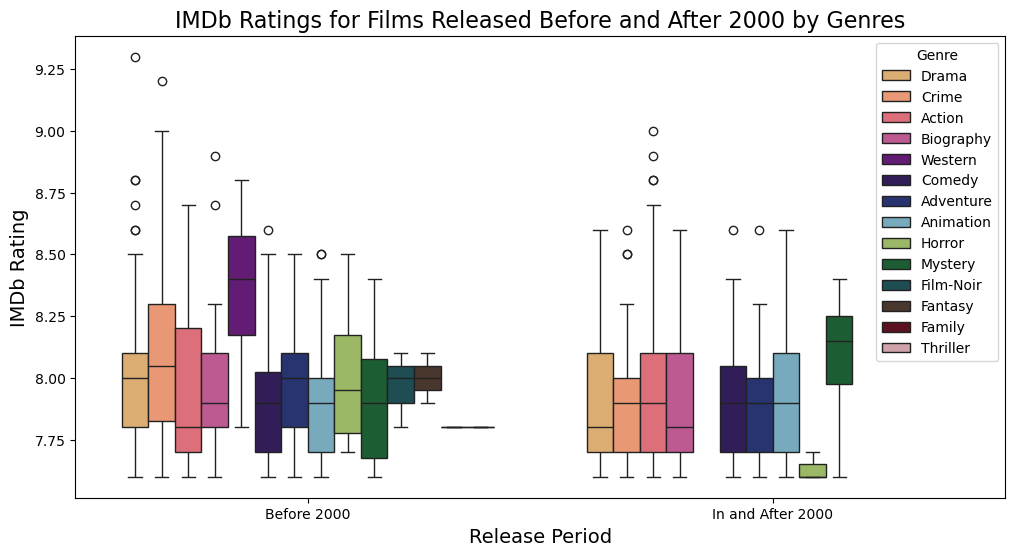

In [ ]:
plt.figure(figsize = (12, 6))
my_palette = sns.color_palette(['#EEAF61', '#FB9062', '#EE5D6C', '#CE4993', '#6A0D83', '#2E1561', '#1C2C7C', '#6CAFCA', '#9FC659', '#126831', '#15545D', '#4E3629', '#68051A', '#D69BA8'])
sns.boxplot(data = movies_data, x = 'Release_Period', y='IMDB_Rating', hue = 'Genre', palette = my_palette)

plt.title('IMDb Ratings for Films Released Before and After 2000 by Genres', fontsize = 16)
plt.xlabel('Release Period', fontsize = 14)
plt.ylabel('IMDb Rating', fontsize = 14)
plt.show()

Many interesting conclusions can be made after looking at the plot above:
1. Western movies tend to receive the highest average IMDb rating of all movies released before 2000.
2. Action movies released before 2000 tend to receive the average IMDb rating of 7.8. However, action movies released in and after 2000 receive the second highest IMDb rating (approximatelly 7.9) after mystery movies. Therefore, action movies released in and after 2000 are rated higher than action movies released before 2000.
3. The popularity of horror movies plunges as the year of release grows.

Let's also create a line plot that is going to demonstrate the relationship between runtime and IMDb rating by different genres. To make it more readable, I am only going to analyse movies IMDb ratings of which are over 8.5, as I would like to take a closer look at the movies with the highest IMDb rating.

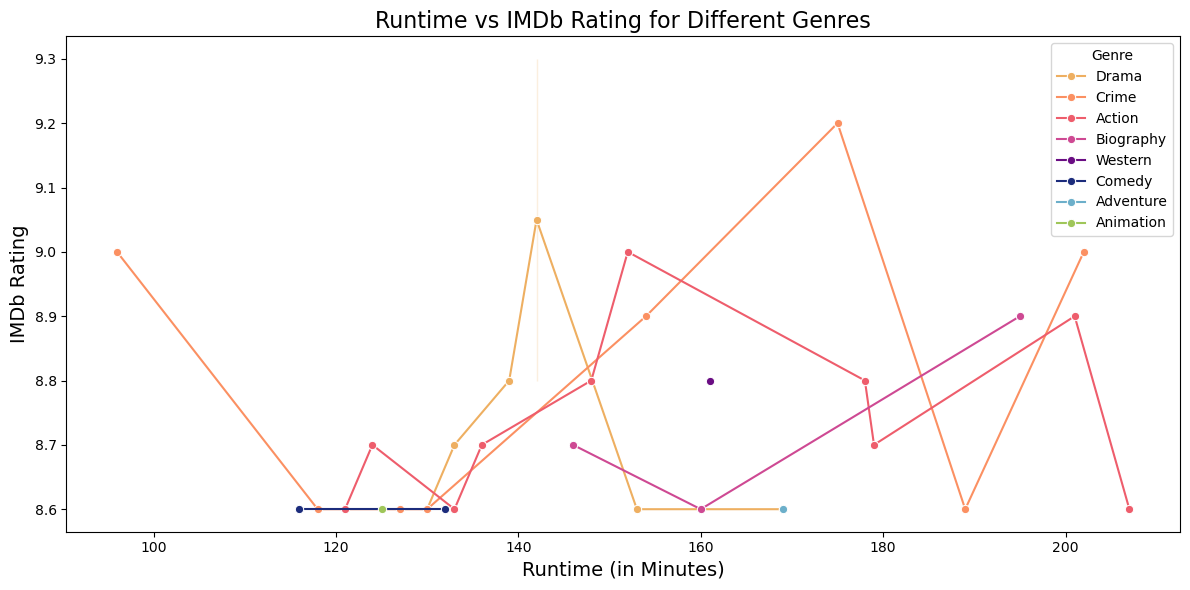

In [ ]:
plt.figure(figsize = (12, 6))
my_palette = sns.color_palette(['#EEAF61', '#FB9062', '#EE5D6C', '#CE4993', '#6A0D83', '#1C2C7C', '#6CAFCA', '#9FC659'])
filtered_data = movies_data[movies_data['IMDB_Rating'] > 8.5]
sns.lineplot(data = filtered_data, x = 'Runtime', y = 'IMDB_Rating', hue = 'Genre', marker='o', palette = my_palette)

plt.title('Runtime vs IMDb Rating for Different Genres', fontsize = 16)
plt.xlabel('Runtime (in Minutes)', fontsize = 14)
plt.ylabel('IMDb Rating', fontsize=14)
plt.legend(title = 'Genre')
plt.tight_layout()
plt.show()


The plot above provides us with a lot of significant insights. Here are some of them:
1. Action movies tend to get the highest IMDb ratings when their runtime is in between 150 and 160 minutes.
2. Crime movies with the runtime of approximately 170 minutes tend to receive the highest IMDb ratings of movies of all genres and runtimes.
3. Drama movies are also rated highly by the viewers when their runtime is equal to 140 minutes.

## Hypothesis check 

Based off the plots I have built, I am now able to summarize all of the information gathered by me and draw a conclusion. 

The keypoints of my hypothesis are:
1. Films released in and after 2000 have higher IMDb ratings than films released before 2000. 
2. Films with longer runtimes released before 2000 receive lower IMDb ratings.
3. Films with longer runtimes released in and after 2000 receive higher IMDb ratings.

Additionally, I wanted to check the correlation between IMDb ratings of the action movies and their release years.

Let's work with every keypoint separately. 

First of all, 'IMDb Ratings by Release Period' plot demostrated a correlation between IMDb rating of a movie and its release year. After looking at the plot, it became apparent that the opposite to my assumption is true: movies released before 2000 tend to het higher IMDb ratings than movies released in the 21st century.

However, even though I disapproved of the first keypoint of my hypothesis, my assumption about correlation between IMDb ratings of the action movies and their release years turned out to be correct. With the help of the 'IMDb Ratings for Films Released Before and After 2000 by Genres' plot I noticed that IMDb ratings of the action movies released in and after 2000 slightly exceed IMDb ratings of the action movies released in the 20th century. 

Secondly, the 'Runtime vs IMDb Rating of Films Released Before 2000' plot made it apparent that the second keypoint of my hypothesis was invalid. Movies with longer runtimes released before 2000 tend to get higher IMDb ratings. Moreover, feature-length movies usually receive lower ratings, which completely disproves my assumption.

Finally, a similar plot was built. The 'Runtime vs IMDb Rating of Films Released In and After 2000' showed almost the exact same pattern as the previous plot. Therefore, the third keypoint of my hypothesis was proved to be correct. 

Overall, my hypothesis turned out to be partly correct. 

## Conclusion 

The analysis conducted by me turned out to be quite interesting! I proved some of the keypoints of my hypothesis to be correct and disproved others. Most importantly, I learned to manage big amounts of data, clean it effectively, and present it in a way that is both readable and visually appealing for the viewer.